In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Data Preprocessing and Data Profile

In [2]:
#read csv files **Make sure to change the file paths**

abm = pd.read_csv("abm.csv")
card = pd.read_csv("card.csv")
cheque = pd.read_csv("cheque.csv")
eft = pd.read_csv("eft.csv")
emt = pd.read_csv("emt.csv")
kyc_individual = pd.read_csv("kyc_individual.csv")
kyc_industry_codes = pd.read_csv("kyc_industry_codes.csv")
kyc_occupation_codes = pd.read_csv("kyc_occupation_codes.csv")
kyc_smallbusiness = pd.read_csv("kyc_smallbusiness.csv")
labels = pd.read_csv("labels.csv")
westernunion = pd.read_csv("westernunion.csv")
wire = pd.read_csv("wire.csv")
merchant_codes = pd.read_csv("mcc_codes.csv")

In [3]:
# data preview
print('✓ Loaded datasets successfully')
print(f'\nDataset sizes:')
print(f'  Wire transfers: {len(wire):,}')
print(f'  Western Union: {len(westernunion):,}')
print(f'  Card transactions: {len(card):,}')
print(f'  EFT transactions: {len(eft):,}')
print(f'  EMT transactions: {len(emt):,}')
print(f'  Individual KYC records: {len(kyc_individual):,}')
print(f'  Small Business KYC records: {len(kyc_smallbusiness):,}')

✓ Loaded datasets successfully

Dataset sizes:
  Wire transfers: 4,956
  Western Union: 2,142
  Card transactions: 3,553,303
  EFT transactions: 1,070,698
  EMT transactions: 845,996
  Individual KYC records: 53,099
  Small Business KYC records: 8,311


In [4]:
#concat the card,cheque, eft, emt, abm, westernunion, wire dataset
eft['type'] = 'eft'
emt['type'] = 'emt'
abm['type'] = 'abm'
card['type'] = 'card'
cheque['type'] = 'cheque'
westernunion['type'] = 'westernunion'
wire['type'] = 'wire'
transactions = pd.concat([card, cheque, eft, emt, abm, westernunion, wire], ignore_index=True)

# merge transactions with labels
data = pd.merge(transactions, labels, on='customer_id', how='left')
transactions

,transaction_id,customer_id,amount_cad,debit_credit,transaction_datetime,merchant_category,ecommerce_ind,country,province,city,type,cash_indicator
0,CARD24110131109543,SYNID0102450742,13.35,D,2024-11-01 00:00:06,5812,1.0,CA,ON,NaN,card,NaN
1,CARD24110136178868,SYNID0105586872,6.05,D,2024-11-01 00:00:17,5968,1.0,NaN,NaN,other,card,NaN
2,CARD24110173783589,SYNID0107901560,81.40,C,2024-11-01 00:00:37,4816,0.0,CA,BC,NaN,card,NaN
3,CARD24110142566805,SYNID0107237475,3.20,D,2024-11-01 00:00:41,5814,0.0,CA,ON,MISSISSAUGA,card,NaN
4,CARD24110150346602,SYNID0109982946,356.03,D,2024-11-01 00:00:51,0,0.0,CA,AB,CALGARY,card,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
5903328,2501312027222151,SYNID0200494373,664383.06,C,2025-01-31,NaN,NaN,NaN,NaN,NaN,wire,NaN
5903329,2501314427775083,SYNID0107588495,6720.80,C,2025-01-31,NaN,NaN,NaN,NaN,NaN,wire,NaN
5903330,2501313191709047,SYNID0108770535,20251.28,C,2025-01-31,NaN,NaN,NaN,NaN,NaN,wire,NaN
5903331,2501318829419846,SYNID0100253336,17410.89,D,2025-01-31,NaN,NaN,NaN,NaN,NaN,wire,NaN


In [5]:
# organize the transaction datetime
transactions['transaction_datetime'] = pd.to_datetime(transactions['transaction_datetime'], format='mixed')
transactions['date'] = transactions['transaction_datetime'].dt.date

In [6]:
# calculate the account age for each customer

# fill missing onboard_date with the date of first transaction
transactions = transactions.sort_values(['customer_id','date'])
first_trans_date = transactions.groupby('customer_id')['date'].min()

kyc_individual['onboard_date'] = pd.to_datetime(kyc_individual['onboard_date']).fillna(
    kyc_individual['customer_id'].map(first_trans_date)
)
kyc_individual['account_age'] = (pd.to_datetime('2025-01-31') - kyc_individual['onboard_date']).dt.days

kyc_smallbusiness['onboard_date'] = pd.to_datetime(kyc_smallbusiness['onboard_date']).fillna(
    kyc_smallbusiness['customer_id'].map(first_trans_date)
)
kyc_smallbusiness['account_age'] = (pd.to_datetime('2025-01-31') - kyc_smallbusiness['onboard_date']).dt.days

kyc_age = pd.concat([kyc_individual[['customer_id','account_age']],kyc_smallbusiness[['customer_id','account_age']]],axis=0)
kyc_age = kyc_age.set_index('customer_id')['account_age']

## Feature Engineering

### Basic transaction features

In [7]:
def create_transaction_features(df, prefix):
    """
    Create comprehensive features from transaction data
    """
    features = df.groupby('customer_id').agg({
    'amount_cad': ['count', 'sum', 'mean', 'std', 'min', 'max', 'median']
})  
    features.columns = [f'{prefix}_{col[1]}' for col in features.columns]
    features[f'{prefix}_coef_variation'] = features[f'{prefix}_std'] / (features[f'{prefix}_mean'] + 1e-6)
    features[f'{prefix}_range'] = features[f'{prefix}_max'] - features[f'{prefix}_min']
    features[f'{prefix}_mean_to_max_ratio'] = features[f'{prefix}_mean'] / (features[f'{prefix}_max'] + 1e-6)
    features[f'{prefix}_std'] = features[f'{prefix}_std'].fillna(0)
    features[f'{prefix}_coef_variation'] = features[f'{prefix}_coef_variation'].fillna(0)
    return features

wire_features = create_transaction_features(wire, 'wire')
wu_features = create_transaction_features(westernunion, 'wu')
card_features = create_transaction_features(card, 'card')
eft_features = create_transaction_features(eft, 'eft')
emt_features = create_transaction_features(emt, 'emt')

In [8]:
all_customers = set()
for df in [wire, westernunion, card, eft, emt]:
    all_customers.update(df['customer_id'].unique())

features = pd.DataFrame({'customer_id': list(all_customers)})
features = features.merge(wire_features, on='customer_id', how='left')
features = features.merge(wu_features, on='customer_id', how='left')
features = features.merge(card_features, on='customer_id', how='left')
features = features.merge(eft_features, on='customer_id', how='left')
features = features.merge(emt_features, on='customer_id', how='left')

features = features.fillna(0)

### Transaction volume

In [9]:
count_cols = [col for col in features.columns if '_count' in col]
sum_cols = [col for col in features.columns if '_sum' in col]
mean_cols = [col for col in features.columns if '_mean' in col and '_to_' not in col]

# transaction counts, amount and average
features['total_trans_count'] = features[count_cols].sum(axis=1)
features['total_trans_volume'] = features[sum_cols].sum(axis=1)
features['avg_trans_volume'] = features['total_trans_volume'] / (features['total_trans_count'] + 1e-6)

# transaction max
max_cols = [col for col in features.columns if '_max' in col and 'ratio' not in col]
features['max_single_trans'] = features[max_cols].max(axis=1)
features['max_to_avg_ratio'] = features['max_single_trans'] / (features['avg_trans_volume'] + 1e-6)

# transaction consistency
std_cols = [col for col in features.columns if '_std' in col and 'to_' not in col]
features['overall_std'] = features[std_cols].mean(axis=1)
features['consistency_score'] = 1 / (features['overall_std'] + 1)

### Channel concentration

In [10]:
# transaction channel diversity
features['channel_diversity'] = (features[count_cols] > 0).sum(axis=1)

# transaction channel concentration using Herfindahl-Hirschman Index. It falls between 1/n (perfectly diversified) and 1 (total concentration)
transaction_shares = features[count_cols].div(features['total_trans_count'] + 1e-6, axis=0)
features['channel_concentration'] = (transaction_shares ** 2).sum(axis=1)

# transaction amount concentration using Herfindahl-Hirschman Index. It falls between 1/n (perfectly diversified) and 1 (total concentration)
amount_shares = features[sum_cols].div(features['total_trans_volume'] + 1e-6, axis=0)
features['amount_concentration'] = (amount_shares ** 2).sum(axis=1)

In [11]:
# transaction volume per channel (percentage)
features['wire_preference'] = features['wire_sum'] / (features['total_trans_volume'] + 1e-6)
features['wu_preference'] = features['wu_sum'] / (features['total_trans_volume'] + 1e-6)
features['card_preference'] = features['card_sum'] / (features['total_trans_volume'] + 1e-6)
features['eft_preference'] = features['eft_sum'] / (features['total_trans_volume'] + 1e-6)
features['emt_preference'] = features['emt_sum'] / (features['total_trans_volume'] + 1e-6)

### Churn ratio in 7 Days

churn = outbound_7d/inbound_7d, meaning total outbound and inbound amount in 7 days. If churn ratio is close to 1, it means the account is receiving and sending nearly the same amount of money, which could be a signal of money laundering.

In [12]:
v_trans = transactions.copy()
v_trans.loc[v_trans["debit_credit"] == "D","amount_cad"] *= -1
v_trans['date'] = pd.to_datetime(v_trans['date'])

# calculate the net flow per account
v_trans['net_flow'] = v_trans.groupby('customer_id')['amount_cad'].cumsum()

In [13]:
# Calculate 7-Day Outbound Volume per Account

v_trans = v_trans.set_index('date')
outbound_7d = v_trans.groupby('customer_id')['amount_cad'].transform(
    lambda x: x.clip(upper=0).abs().rolling('7D').sum()
)

In [14]:
# Calculate 7-Day Inbound Volume per Account

inbound_7d = v_trans.groupby('customer_id')['amount_cad'].transform(
    lambda x: x.clip(lower=0).abs().rolling('7D').sum()
)

In [15]:
# Calculate churn ratio

v_trans['churn_ratio'] = outbound_7d / (inbound_7d + 1e-6)

In [16]:
# Calculate local Z-score of Churn Ratio for each account

# sum and sum of squared per account
stats = v_trans.groupby('customer_id')['churn_ratio'].agg(['sum', lambda x: (x**2).sum()]).reset_index()
stats.columns = ['customer_id', 'churn_sum', 'churn_sum_sq']

# User account age as denominator
window=(pd.to_datetime('2025-01-31')-pd.to_datetime('2024-11-01')).days
stats['onboard_days'] = stats['customer_id'].map(kyc_age).clip(upper=window, lower=1)

# mean and std
stats['churn_mean'] = stats['churn_sum'] / (stats['onboard_days']+1e-6)
inner_val = (stats['churn_sum_sq'] / (stats['onboard_days']+1e-6)) - (stats['churn_mean']**2)
stats['churn_std'] = np.sqrt(inner_val.clip(lower=0)).fillna(0)

# Z-score
v_trans = v_trans.merge(stats[['customer_id', 'churn_mean', 'churn_std']], on='customer_id')
v_trans['churn_z_score'] = (v_trans['churn_ratio'] - v_trans['churn_mean']) / (v_trans['churn_std']+1e-6)

In [17]:
# construct flags for each transaction

# if churn_z_score is larger than 3, the amount outbound and inbound in 7d over time is very volatile. So it is abnormal and suspicious.
v_trans['is_anomaly'] = (v_trans['churn_z_score'] > 3).astype(int)

# if churn ratio is near 1, the amount outbound and inbound in 7d is nearly the same. So it is symmetric and suspicious
v_trans['is_symmetric'] = (v_trans['churn_ratio'].between(0.9, 1.1)).astype(int)

In [18]:
# Aggregate transaction-level flags to account level

# aggregate to account Level
churn_ratio = v_trans.groupby('customer_id').agg({
    'is_anomaly': 'sum',                 # Count of Z > 3 events
    'is_symmetric': 'sum',               # Count of 0.9-1.1 churn events
}).reset_index()

churn_ratio.columns = ['customer_id','churn_anomaly_count', 'churn_symmetry_count']

features = features.merge(churn_ratio,on='customer_id',how='left')

### __-to-income/sales ratio features

In [19]:
# estimate incomes for individuals whose income's missing

# Assign 0 income to the unemployed,retired and student
fill_values = {
    'UNEMPLOYED': 0,
    'RETIRED': 0,
    'STUDENT': 0
}

for occupation, value in fill_values.items():
    mask = (kyc_individual['occupation_code'] == occupation) & (kyc_individual['income'].isna())
    kyc_individual.loc[mask, 'income'] = value

# In these missing observations, assign median income for the others
kyc_individual['income'] = kyc_individual['income'].fillna(
    kyc_individual.groupby('occupation_code')['income'].transform('median')
)

# fill individuals that don't have occupation information with 0 income
kyc_individual['income'] = kyc_individual['income'].fillna(0)

In [20]:
# estimate sales for small businesses whose sales's missing

# assign median sales for those missing values with same industry code
kyc_smallbusiness['sales'] = kyc_smallbusiness['sales'].fillna(
    kyc_smallbusiness.groupby('industry_code')['sales'].transform('median')
)

# fill companies that don't have occupation information with 0 sales
kyc_smallbusiness['sales'] = kyc_smallbusiness['sales'].fillna(0)

In [21]:
# compute total outbound amount for each account
v_trans = transactions.copy()
v_trans.loc[v_trans["debit_credit"] == "D","amount_cad"] *= -1
total_outbound = v_trans.groupby('customer_id')['amount_cad'].apply(
    lambda x: x.clip(upper=0).abs().sum()
).reset_index(name='total_outbound_amount')
features = features.merge(total_outbound,on='customer_id',how='left')

In [22]:
# outbound_to_income ratio (for individuals)

outbound_income_ratio = total_outbound.merge(kyc_individual[['customer_id','income','account_age']],on='customer_id',how='left')
window=(pd.to_datetime('2025-01-31')-pd.to_datetime('2024-11-01')).days
outbound_income_ratio['onboard_days'] = outbound_income_ratio['customer_id'].map(kyc_age).clip(upper=window, lower=1)
outbound_income_ratio['income'] = outbound_income_ratio['onboard_days'] * outbound_income_ratio['income']/365
outbound_income_ratio['outbound_to_income_ratio'] = outbound_income_ratio['total_outbound_amount']/(outbound_income_ratio['income']+ 1e-6)
features = features.merge(outbound_income_ratio[['customer_id','income','outbound_to_income_ratio']],on='customer_id',how='left')

In [23]:
# outbound_to_sales ratio (for small businesses)

revenue_capacity_ratio = total_outbound.merge(kyc_smallbusiness[['customer_id','sales','account_age']],on='customer_id',how='left')
window=(pd.to_datetime('2025-01-31')-pd.to_datetime('2024-11-01')).days
revenue_capacity_ratio['onboard_days'] = revenue_capacity_ratio['customer_id'].map(kyc_age).clip(upper=window, lower=1)
revenue_capacity_ratio['sales'] = revenue_capacity_ratio['onboard_days'] * revenue_capacity_ratio['sales']/365
revenue_capacity_ratio['revenue_capacity_ratio'] = revenue_capacity_ratio['total_outbound_amount']/(revenue_capacity_ratio['sales']+1e-6)
features = features.merge(revenue_capacity_ratio[['customer_id','sales','revenue_capacity_ratio']],on='customer_id',how='left')

In [45]:
# total volume_to_income ratio
features['ttl_volume_to_income'] = features['total_trans_volume'] / (features['income'] + 1e-6)
# total volume_to_sales ratio
features['ttl_volume_to_sales'] = features['total_trans_volume'] / (features['sales'] + 1e-6)

# total transactions count to income ratio
features['trans_count_to_income'] = features['total_trans_count'] / (features['income'] + 1e-6)
# total transactions count to sales ratio
features['trans_count_to_sales'] = features['total_trans_count'] / (features['sales'] + 1e-6)

# average volume_to_income ratio
features['avg_volume_to_income'] = features['avg_trans_volume'] / (features['income'] + 1e-6)
# average volume_to_income ratio
features['avg_volume_to_sales'] = features['avg_trans_volume'] / (features['sales'] + 1e-6)


is_individual = features['customer_id'].isin(kyc_individual['customer_id'])
is_smallbusiness = features['customer_id'].isin(kyc_smallbusiness['customer_id'])
features.loc[is_individual,['ttl_volume_to_sales','trans_count_to_sales','avg_volume_to_sales','revenue_capacity_ratio']] = 0
features.loc[is_smallbusiness,['ttl_volume_to_income','trans_count_to_income','avg_volume_to_income','outbound_to_income_ratio']] = 0

### Age and account age

In [25]:
# add account age info to account profile
features = features.merge(kyc_age,on='customer_id',how='left')

In [26]:
# add customer age info to account profile
kyc_individual['age'] = ((pd.to_datetime('2025-1-31')-pd.to_datetime(kyc_individual.birth_date)).dt.days/365.25).fillna(0).astype(int)
features = features.merge(kyc_individual[['customer_id','age']],on='customer_id',how='left')
features['age'] = features['age'].replace(0,np.nan)

### Time Frequency features

The hypothesis tested in this work is that, the fundamental energy distribution characteristics of time-frequency representation of suspicious and non-suspicious entities will be different. We use a short-time fourier transformer to extract time frequency features

In [27]:
# Build stft transformer
v_trans = transactions.copy()
v_trans.loc[v_trans["debit_credit"] == "D","amount_cad"] *= -1
daily_trans=v_trans.groupby(['customer_id','date'])['amount_cad'].sum().rename('net_flow_per_day').reset_index()
daily_trans

,customer_id,date,net_flow_per_day
0,SYNID0100000167,2024-11-03,42.05
1,SYNID0100000167,2024-11-08,-151.36
2,SYNID0100000167,2024-11-14,984.14
3,SYNID0100000167,2024-11-15,-97.07
4,SYNID0100000167,2024-12-01,-253.16
...,...,...,...
2792589,SYNID0200999998,2025-01-02,0.00
2792590,SYNID0200999998,2025-01-03,-42.73
2792591,SYNID0200999998,2025-01-06,-230.44
2792592,SYNID0200999998,2025-01-08,-38.79


In [28]:
# create a signal 

def get_customer_signal(daily, customer_id):
    s = (
        daily[daily['customer_id'] == customer_id]
        .set_index('date')
        .sort_index()['net_flow_per_day']
    )

    # Fill missing days with 0
    s = s.asfreq('D', fill_value=0)

    return s.values  # return the daily signal: an array of transactions each day

In [29]:
# use stft with sliding window
from scipy.signal import stft

# compute stft per customer
def compute_tf_matrix(signal,window_days,step_days=1):   # can set the window days to be 7,15,30
    """
    returns: |STFT| magnitude (time * frequency)
    """
    n = len(signal)
    nperseg = min(window_days, n)
    noverlap = min(nperseg - 1, nperseg - step_days)

    f, t, Zxx = stft(
        signal,
        nperseg=nperseg,
        noverlap=noverlap,
        boundary=None
    )

    # Use magnitude
    tf_matrix = np.abs(Zxx)

    return f,t,tf_matrix  # shape: (freq_bins, time_bins)

In [30]:
# Plot heatmap of signal

def plot_tf_matrix(t,f,tf_matrix):
    plt.figure(figsize=(12, 6))
    plt.pcolormesh(t, f, tf_matrix)
    plt.title('Transaction Rhythms Over Time')
    plt.ylabel('Frequency (Cycles per Day)')
    plt.xlabel('Time (Days)')
    plt.colorbar(label='Magnitude (Intensity of Rhythm)')
    plt.grid(alpha=0.2)
    plt.show

Sample normalized stft representation

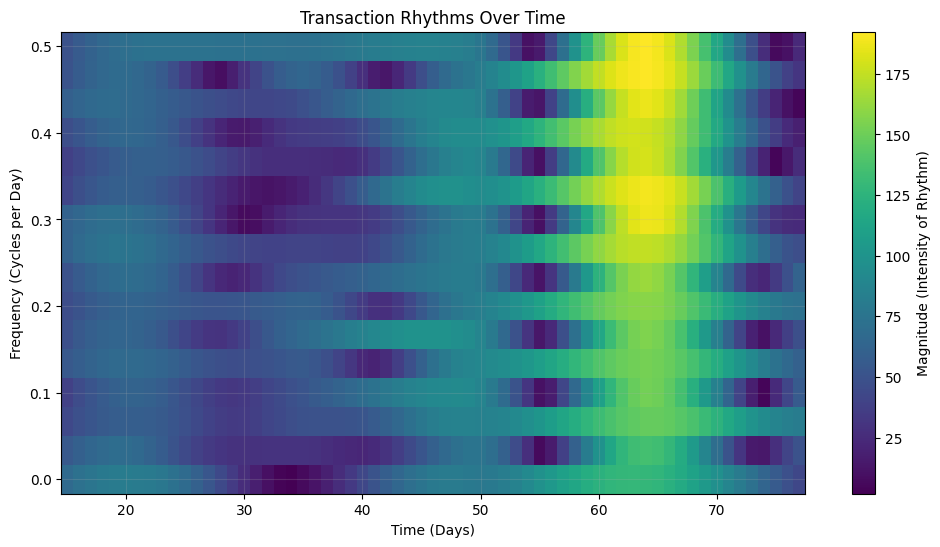

In [31]:
signal_nonfraud = get_customer_signal(daily_trans,'SYNID0100000485')   # SYNID0100000485 is non-fraud

# larger window sizes are good for detecting periodic smurfing transactions. smaller window sizes are good for detecting burst of transactions
f,t,tf_matrix = compute_tf_matrix(signal_nonfraud,30,1)  # set window days to 30 here to catch weekly cycles
plot_tf_matrix(t,f,tf_matrix)

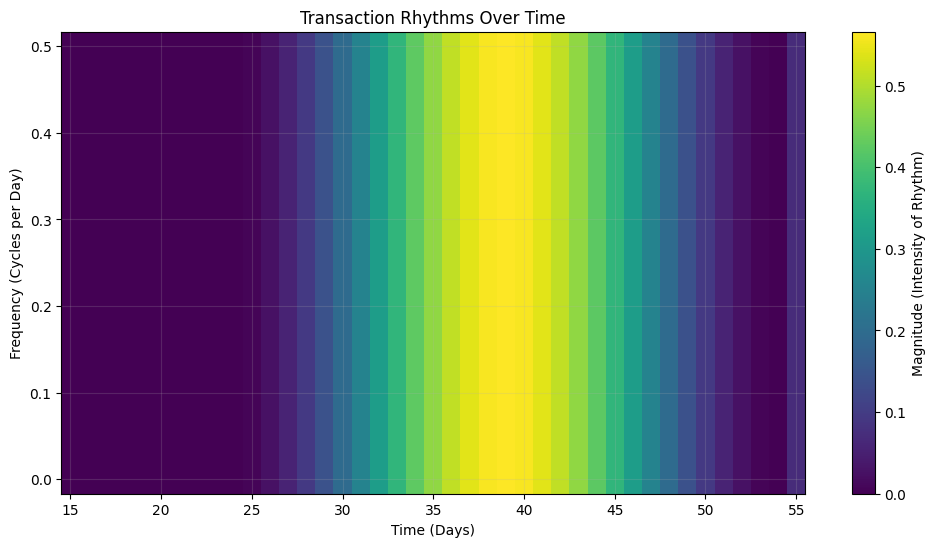

In [32]:
signal_fraud = get_customer_signal(daily_trans,'SYNID0101421130')   # SYNID0101421130 is fraud
f,t,tf_matrix = compute_tf_matrix(signal_fraud,30,1)  # set window days to 30
plot_tf_matrix(t,f,tf_matrix)

represent the tf matrix with features

In [33]:
# to cut time effectively, we compute the batch stft for all customers

def get_all_signals_matrix(df):
    """
    Returns: 
        signals_array: Numpy array (Days x Customers)
        customer_ids: List of customer IDs
    """
    print("Step 1: Creating Customer Signals Matrix...")
    
    # Pivot table
    matrix = df.pivot_table(
        index='date', 
        columns='customer_id', 
        values='net_flow_per_day', 
        fill_value=0
    )
    
    # Ensure daily frequency and fill missing days with 0
    matrix = matrix.asfreq('D', fill_value=0)
    
    return matrix.values, matrix.columns

In [34]:
def compute_batch_stft(signals_array, window_days, step_days=1):
    """
    Computes STFT for all customers simultaneously using vectorization.
    Input: 2D Array (Days x Customers)
    Output: 3D Tensor (Frequencies x TimeBins x Customers)
    """
    print("Step 2: Computing STFT for all customers...")
    
    nperseg = window_days
    noverlap = nperseg - step_days
    
    # axis=0 tells scipy to run down the time column for everyone
    f, t, Zxx = stft(
        signals_array, 
        nperseg=nperseg, 
        noverlap=noverlap, 
        axis=0, 
        boundary=None
    )
    
    # Return the magnitude
    return np.abs(Zxx)

In [35]:
from scipy.stats import skew, kurtosis

def extract_all_tf_features(tf_tensor, customer_ids):

    print(f"1. Received Tensor Shape: {tf_tensor.shape}")
    
    num_customers = len(customer_ids)
    shape = tf_tensor.shape
    
    # auto-correlation strp: ensure shape is (Freq, Time, Customers)
    
    if shape[2] == num_customers:
        pass
        
    elif shape[0] == num_customers:
        tf_tensor = tf_tensor.transpose(1, 2, 0)
        
    elif shape[1] == num_customers:
        tf_tensor = tf_tensor.transpose(0, 2, 1)
        
    else:
        raise ValueError(f"Tensor shape {shape} does not match customer count {num_customers}!")

    print(f"2. Processing Corrected Tensor: {tf_tensor.shape}...")


    # Flatten Frequency and Time
    n_freqs, n_times, n_cust = tf_tensor.shape
    
    # ensure memory is contiguous for reshape
    tf_tensor = tf_tensor.copy()
    tf_flat = tf_tensor.reshape(-1, n_cust) 
    
    # caluclate the energy
    time_energy = tf_tensor.sum(axis=0) # Sum over Freq -> (Time, Cust)
    freq_energy = tf_tensor.sum(axis=1) # Sum over Time -> (Freq, Cust)
    
 
    # 1. average energy across the window --> the average transaction intensity
    tf_mean = tf_flat.mean(axis=0)

    # 2. variance of energy --> represent if there are extreme highs and lows in their transactions
    tf_var = tf_flat.var(axis=0)    

    # 3. asymmetry & tailedness --> anomalous bursts that deviate significantly from the norm
    tf_kurt = kurtosis(tf_flat, axis=0, fisher=False)
    mask_low_var = tf_var < 1e-10
    tf_kurt[mask_low_var] = 0
    
    # 4. measures sudden burst in volumes from one day to the next
    disc_time = np.abs(np.diff(tf_tensor, axis=1)).mean(axis=(0, 1))

    # 5. measures sudden change in rhythm of transactions
    disc_freq = np.abs(np.diff(tf_tensor, axis=0)).mean(axis=(0, 1))

    # 6. measure simultaneous shifts in time and frequency
    term1 = tf_tensor[:-1, :-1, :] 
    term2 = tf_tensor[1:, 1:, :]   
    term3 = tf_tensor[1:, :-1, :]  
    term4 = tf_tensor[:-1, 1:, :] 
    disc_tf = np.abs(term1 + term2 - term3 - term4).mean(axis=(0, 1))
    
    # 7. Entropy: unpredictability of the signal
    total_energy = tf_flat.sum(axis=0, keepdims=True) + 1e-12
    p = tf_flat / total_energy
    tf_entropy = -np.sum(p * np.log(p + 1e-12), axis=0)
    
    # 8. percentage of time that's inactive
    sparsity_time = (time_energy <= 1e-6).mean(axis=0)

    # 9. measures if the user lacks any dominant rhythm
    sparsity_freq = (freq_energy <= 1e-6).mean(axis=0)

    # 10. overall emptiness --> dormant accounts
    sparsity_tf   = (tf_flat <= 1e-6).mean(axis=0)


    data = {
        'tf_mean': tf_mean,
        'tf_var': tf_var,
        'tf_kurt': tf_kurt,
        'sparsity_time': sparsity_time,
        'sparsity_freq': sparsity_freq,
        'sparsity_tf': sparsity_tf,
        'disc_time': disc_time,
        'disc_freq': disc_freq,
        'disc_tf': disc_tf,
        'tf_entropy': tf_entropy
    }
    
    return pd.DataFrame(data, index=customer_ids)

In [36]:
# Window Days = 30
signals, cust_ids = get_all_signals_matrix(daily_trans)
tf_tensor30 = compute_batch_stft(signals, window_days=30, step_days=1)  # set window days to be 30
tf_features30 = extract_all_tf_features(tf_tensor30, cust_ids)
print('Window = 30, Done!')

Step 1: Creating Customer Signals Matrix...
Step 2: Computing STFT for all customers...
1. Received Tensor Shape: (16, 61410, 63)
2. Processing Corrected Tensor: (16, 63, 61410)...
Window = 30, Done!


In [37]:
features = features.merge(tf_features30,on='customer_id',how='left')

### Account activity days

In [38]:
# unique active days

unique_days = transactions.groupby('customer_id')['transaction_datetime'].apply(
    lambda x: x.dt.date.nunique()
).reset_index()
unique_days.columns = ['customer_id', 'unique_active_days']

In [39]:
active_features = transactions.groupby('customer_id').agg(
    first_transaction_date=('transaction_datetime', 'min'),
    last_transaction_date=('transaction_datetime', 'max')
)
active_features.rename(columns={
    'transaction_datetime_min': 'first_transaction_date',
    'transaction_datetime_max': 'last_transaction_date'
}, inplace=True)

# account activity days
active_features['account_activity_days'] = (
    active_features['last_transaction_date'] - 
    active_features['first_transaction_date']
).dt.days + 1

# activity density days
active_features = active_features.merge(unique_days,on='customer_id',how='left')
active_features['activity_density'] = (
    active_features['unique_active_days'] / 
    active_features['account_activity_days']
)

In [40]:
features = features.merge(active_features[['customer_id','unique_active_days','account_activity_days','activity_density']],on='customer_id',how='left')

### transaction velocity

In [41]:
# Calculate velocity variance
def calculate_velocity_variance(customer_transactions):
    customer_transactions = customer_transactions.sort_values('transaction_datetime')
    customer_transactions = customer_transactions.set_index('transaction_datetime')
    
    daily_counts = customer_transactions.resample('D').size()
    rolling_7day = daily_counts.rolling(window=7, min_periods=1).sum()
    velocity_variance = rolling_7day.var()
    
    return velocity_variance

# Apply to all customers
velocity_variance = transactions.groupby('customer_id').apply(
    calculate_velocity_variance,
    include_groups=False
).reset_index()
velocity_variance.columns = ['customer_id', 'velocity_variance_7day']

# Merge with features
features = features.merge(velocity_variance, on='customer_id', how='left')
features = features.assign(
    velocity_variance_7day=features['velocity_variance_7day'].fillna(0)
)

In [ ]:
#features.to_csv('features.csv',index=False)

## Data Pre-processing for model training

### Correlation matrix to reduce feature numbers

<Axes: >

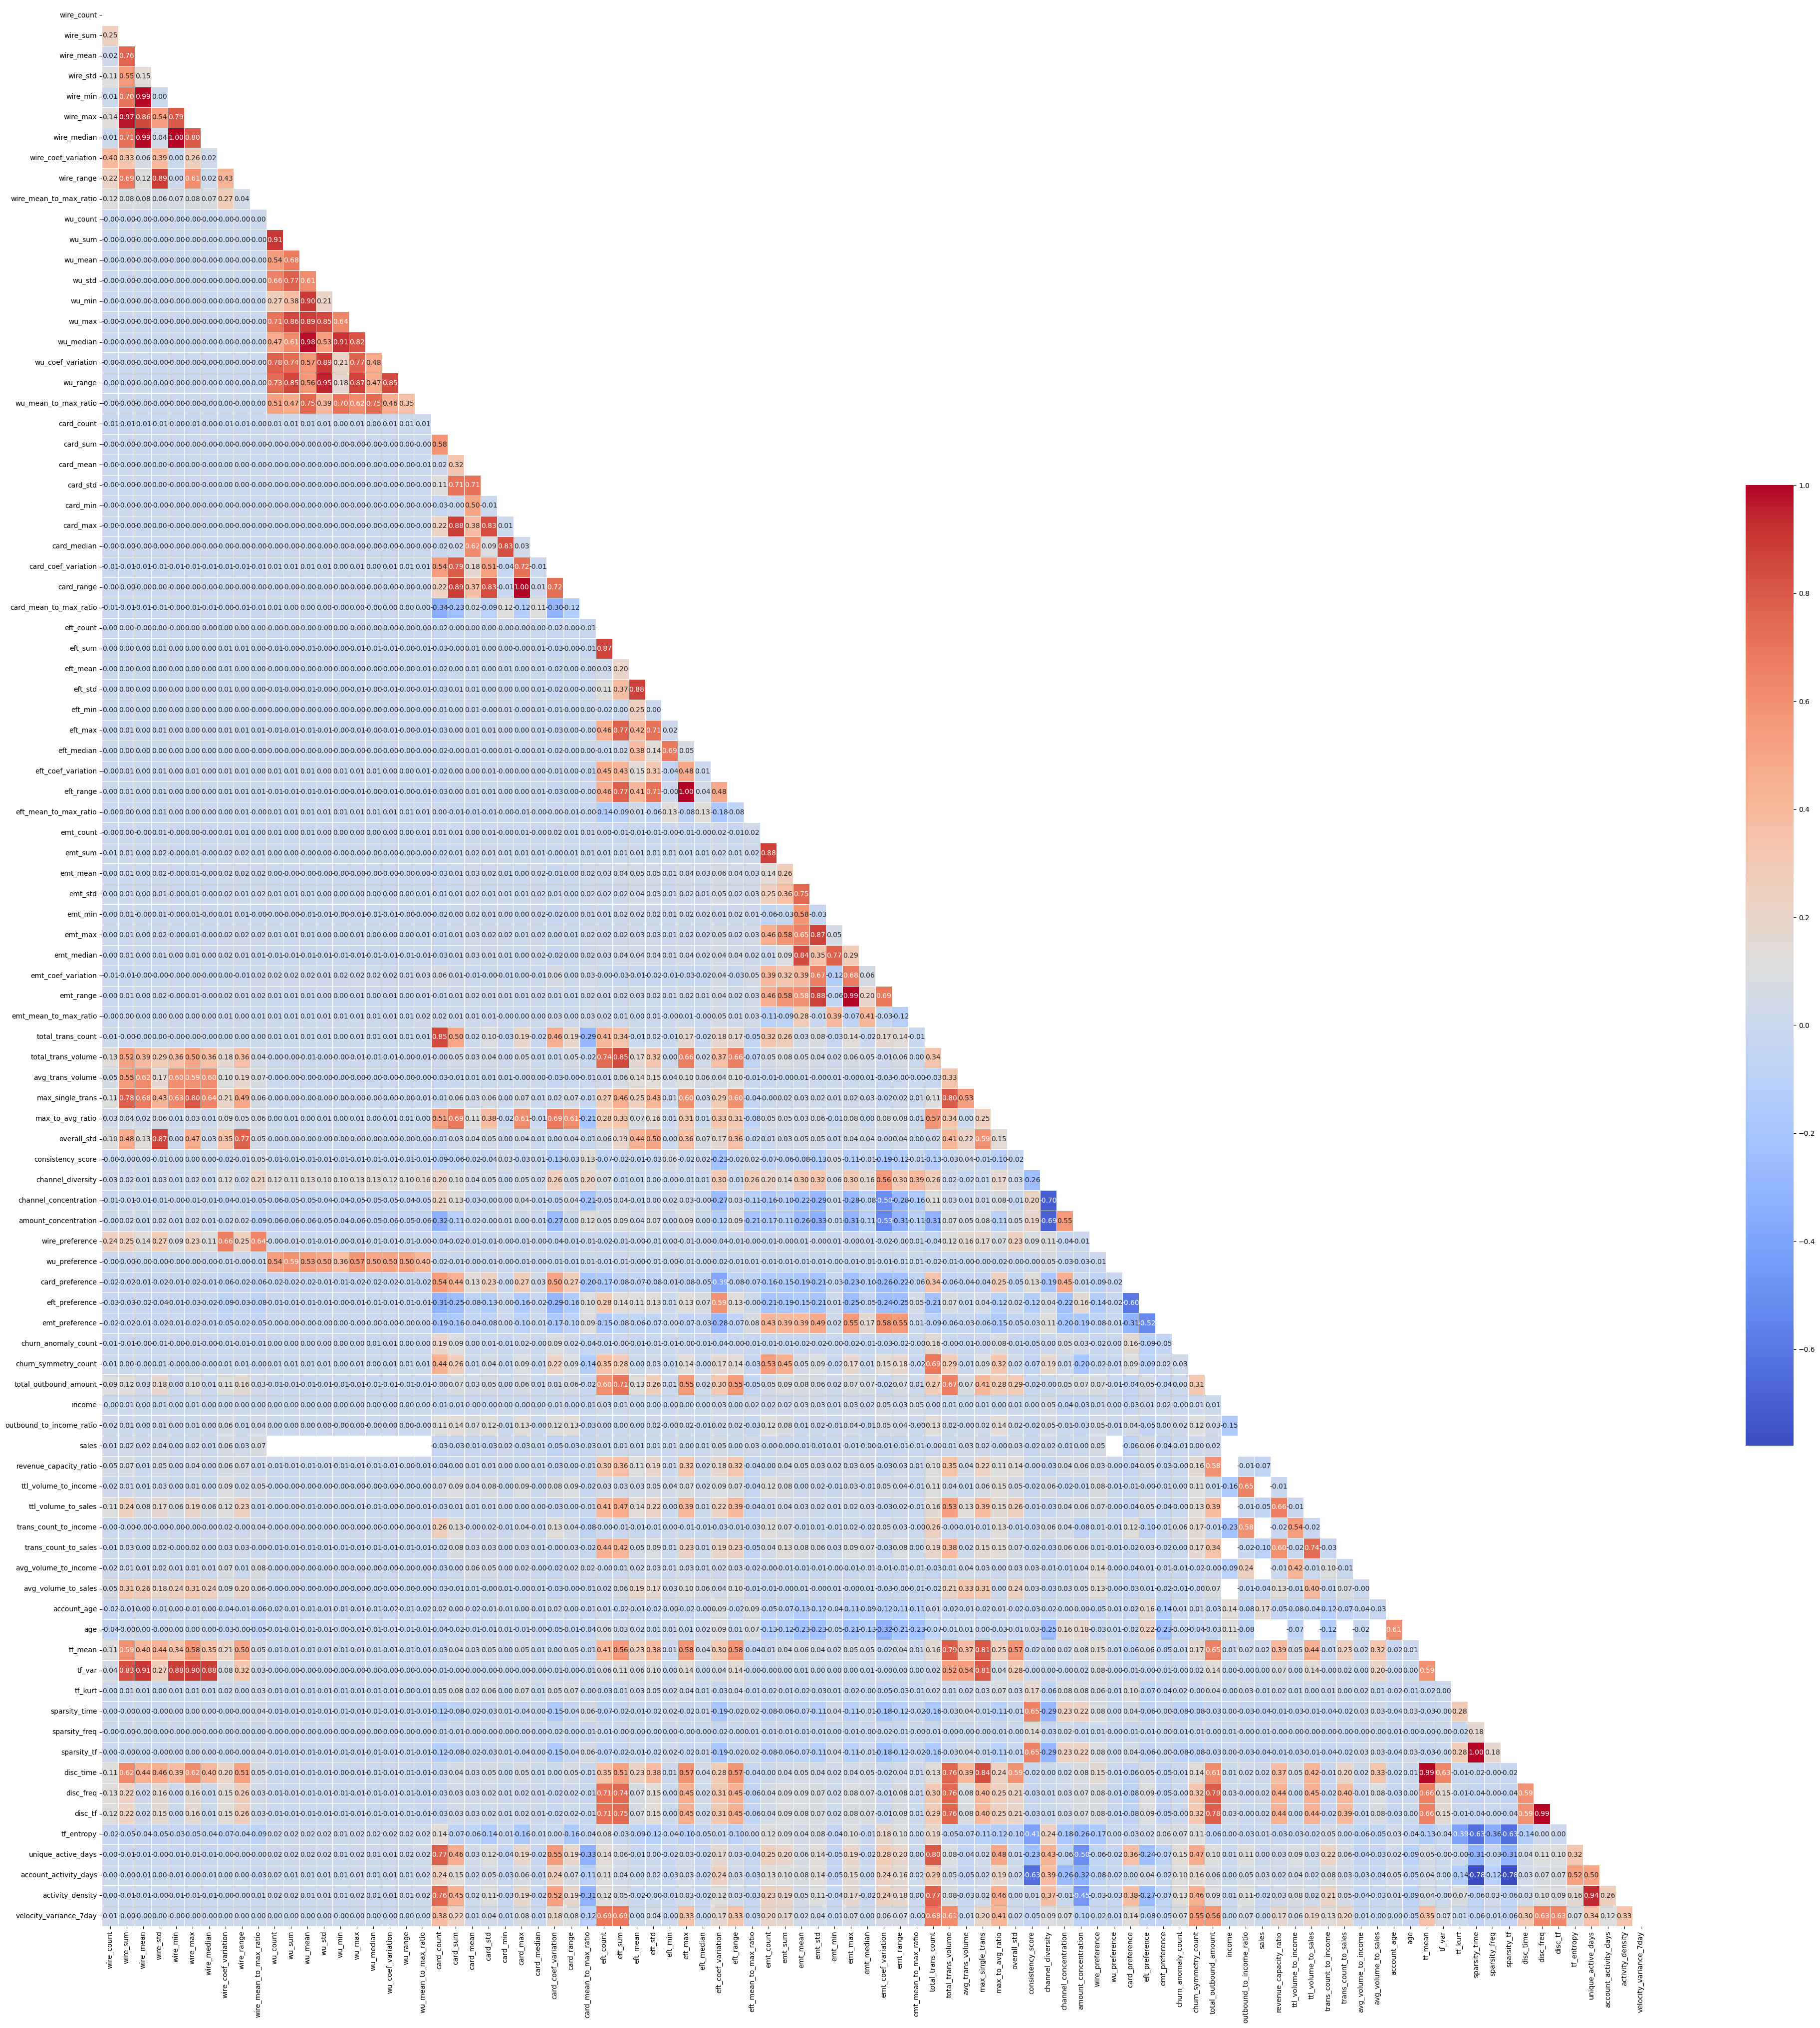

In [61]:
import seaborn as sns
import numpy as np

correlation_matrix = features.drop(columns='customer_id').corr()
mask = np.zeros_like(correlation_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

plt.figure(figsize=(50,50))
sns.heatmap(
    correlation_matrix,
    mask=mask,          # Apply the mask
    annot=True,
    cmap='coolwarm',    
    fmt=".2f",
    linewidths=0.5, 
    cbar_kws={"shrink": .5}
)

In [63]:
# check correlations > 0.8

upper_tri = correlation_matrix.abs().where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

corr_pairs = upper_tri.unstack()
high_corr = corr_pairs[corr_pairs >= 0.8]
high_corr_sorted = high_corr.sort_values(ascending=False)
print(high_corr_sorted)

sparsity_tf         sparsity_time         1.000000
eft_range           eft_max               0.999812
card_range          card_max              0.999807
wire_median         wire_min              0.996799
disc_tf             disc_freq             0.993598
emt_range           emt_max               0.993419
wire_median         wire_mean             0.992259
disc_time           tf_mean               0.992116
wire_min            wire_mean             0.988299
wu_median           wu_mean               0.984658
wire_max            wire_sum              0.972018
wu_range            wu_std                0.949508
activity_density    unique_active_days    0.943713
wu_median           wu_min                0.911881
tf_var              wire_mean             0.906879
wu_sum              wu_count              0.905511
tf_var              wire_max              0.899173
wu_min              wu_mean               0.895177
wu_coef_variation   wu_std                0.893038
wire_range          wire_std   

In [71]:
# drop one of the features in a pair
features_reduced = features.drop(columns=['sparsity_time','eft_max','card_max','wire_median','disc_freq','emt_max','tf_mean','wire_min',
                                          'wu_median','wire_max','wu_range','unique_active_days','wu_median','tf_var','wu_count','wu_min',
                                          'wu_coef_variation','wire_range','card_range','eft_mean','emt_count','emt_range','eft_count','overall_std',
                                          'eft_sum','emt_median','max_single_trans','card_max','wu_max','card_median','card_count'])

<Axes: >

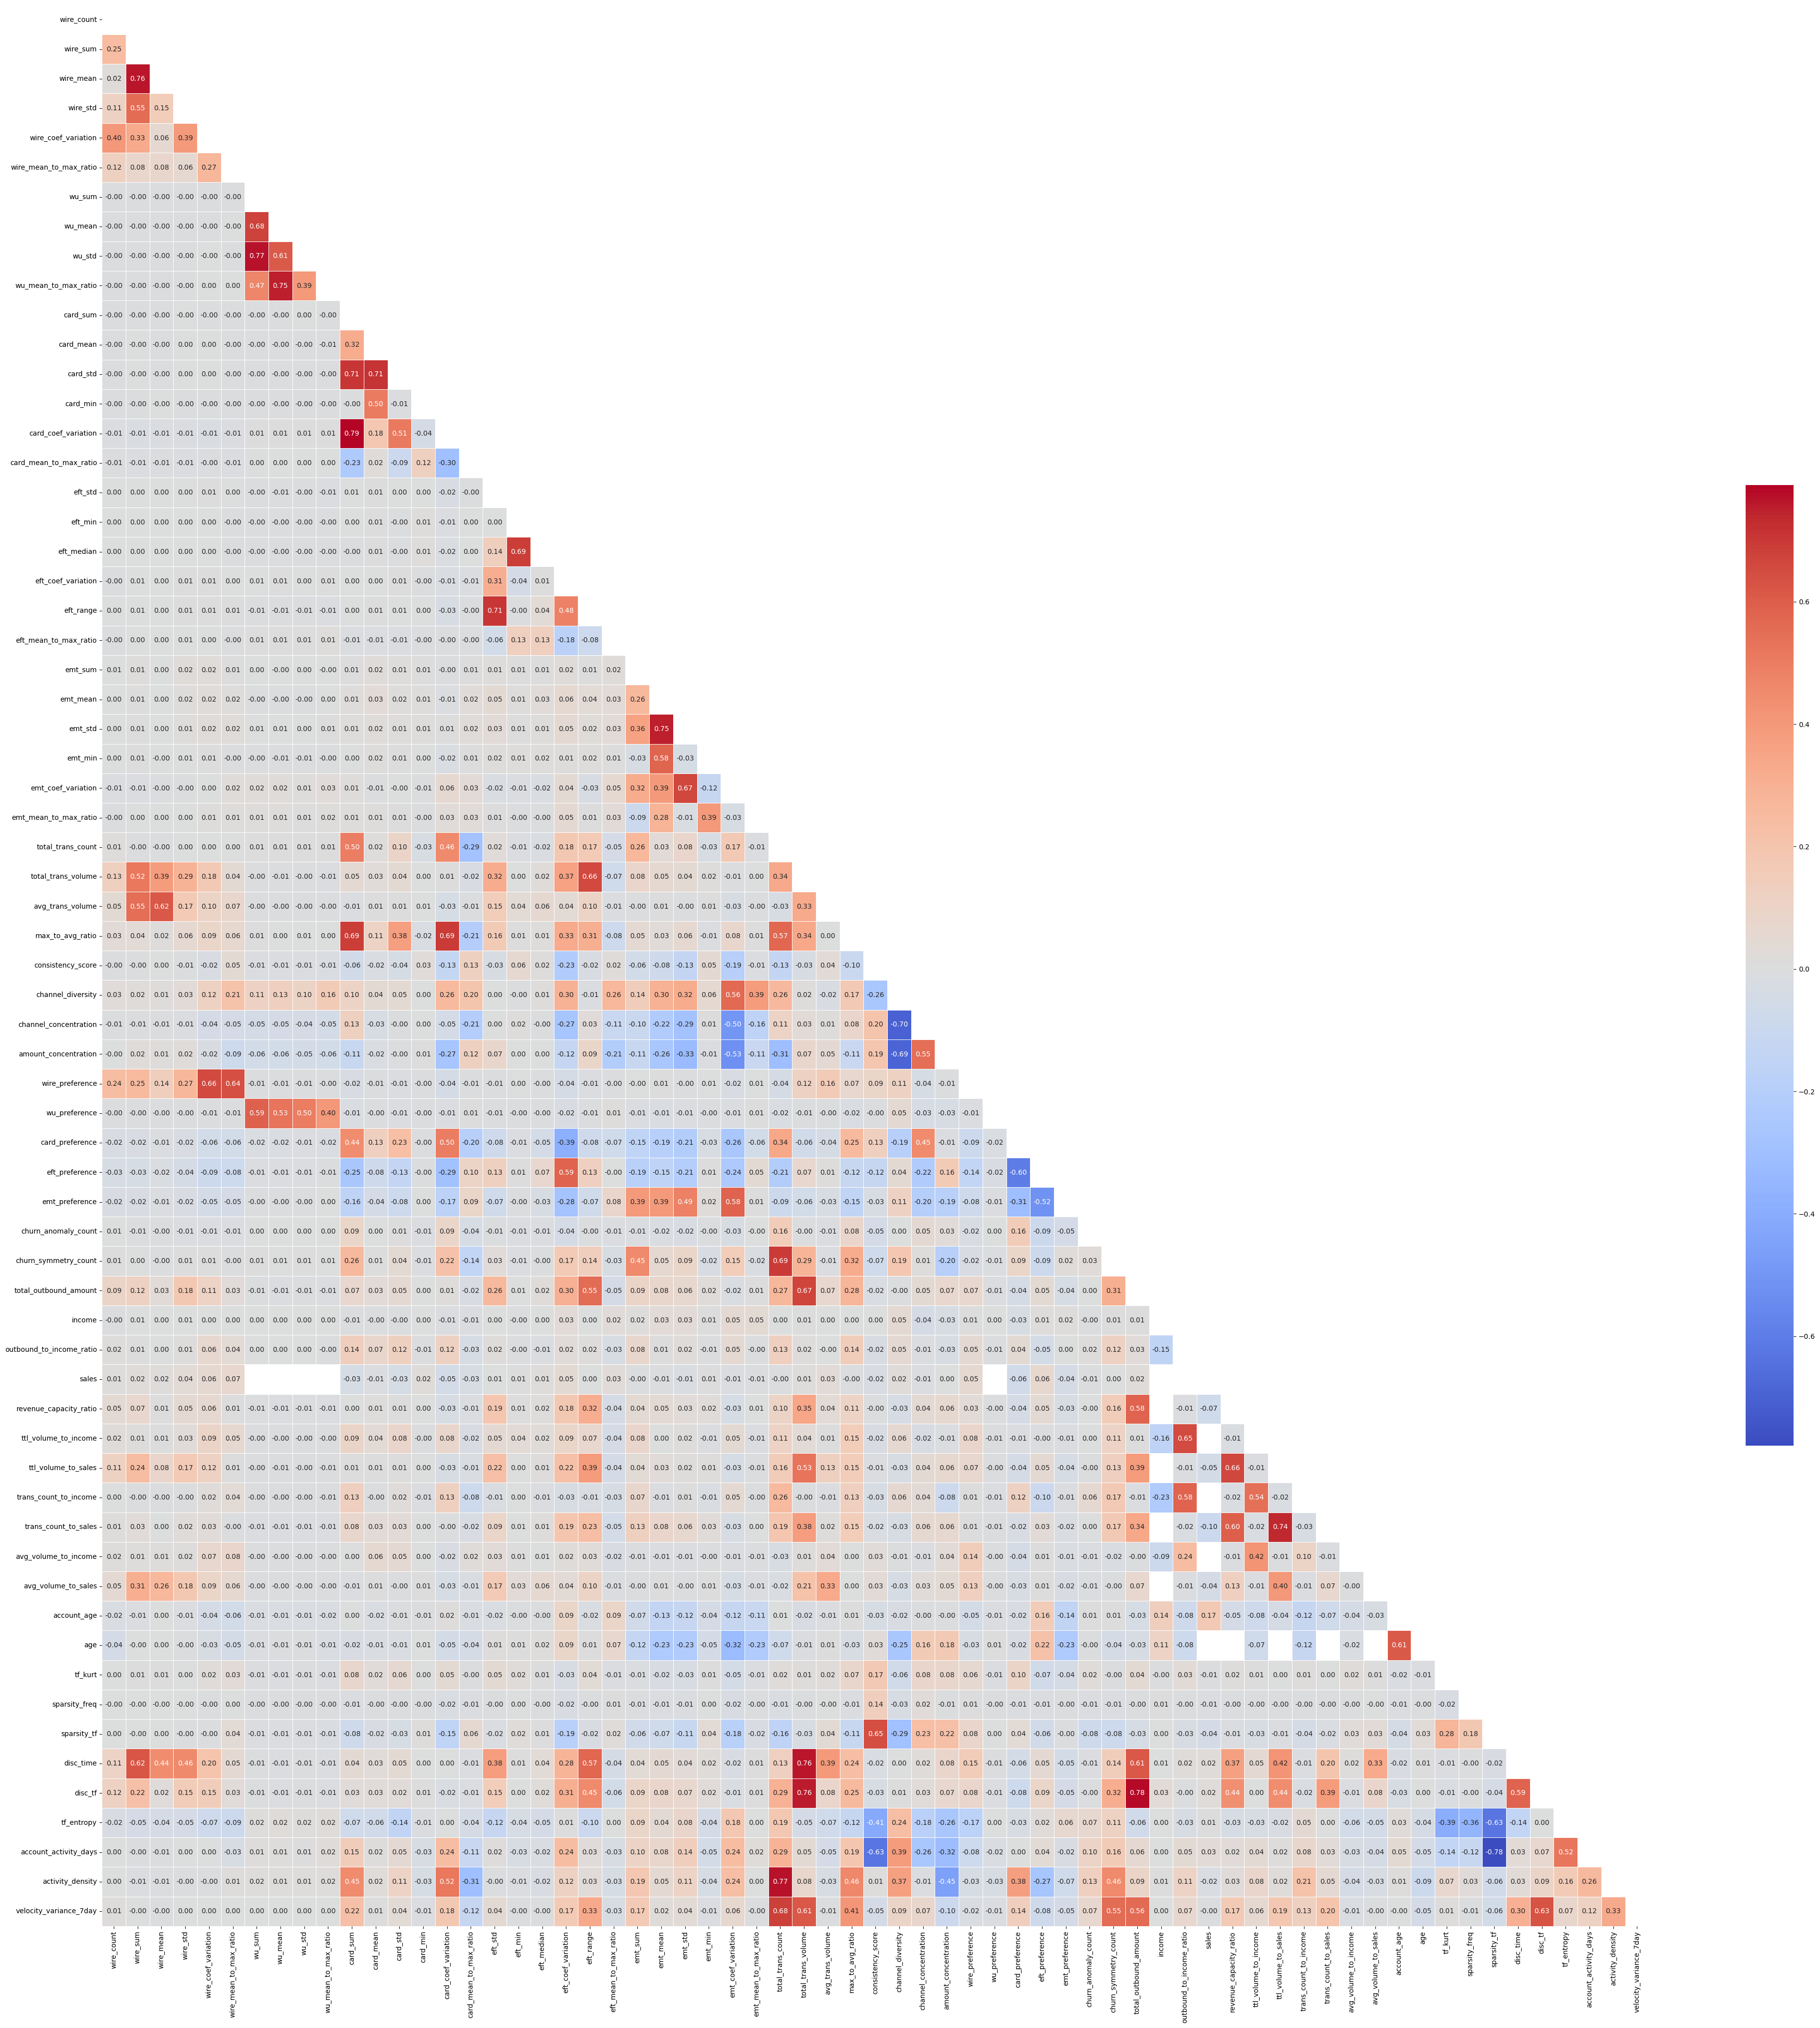

In [72]:
correlation_matrix_reduced = features_reduced.drop(columns='customer_id').corr()
mask = np.zeros_like(correlation_matrix_reduced, dtype=bool)
mask[np.triu_indices_from(mask)] = True

plt.figure(figsize=(50,50))
sns.heatmap(
    correlation_matrix_reduced,
    mask=mask,          # Apply the mask
    annot=True,
    cmap='coolwarm',    
    fmt=".2f",
    linewidths=0.5, 
    cbar_kws={"shrink": .5}
)

### Supervised learning to filter features

In [188]:
# merge with the labels

features_reduced_new = features_reduced.merge(labels,on='customer_id',how='right')
individual_features = features_reduced_new[features_reduced_new['customer_id'].isin(kyc_individual['customer_id'])].drop(columns=['ttl_volume_to_sales','trans_count_to_sales','avg_volume_to_sales','revenue_capacity_ratio'])
business_features = features_reduced_new[features_reduced_new['customer_id'].isin(kyc_smallbusiness['customer_id'])].drop(columns=['ttl_volume_to_income','trans_count_to_income','avg_volume_to_income','outbound_to_income_ratio'])

#### individual important features

In [189]:
from xgboost import XGBClassifier

X = individual_features.drop(columns=['customer_id','label']) 
y = individual_features['label']

# Calculate the ratio of normal accounts to flagged to handle the extreme imbalance
scale_weight = len(y[y == 0]) / len(y[y == 1])

# Initialize XGBoost with the scale_pos_weight to force it to care about the rare flagged
xgb_model = XGBClassifier(
    scale_pos_weight=scale_weight,
    eval_metric='logloss',
    max_depth=4,        # shallow to prevent overfitting
    random_state=42
)

# Train the model
xgb_model.fit(X, y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

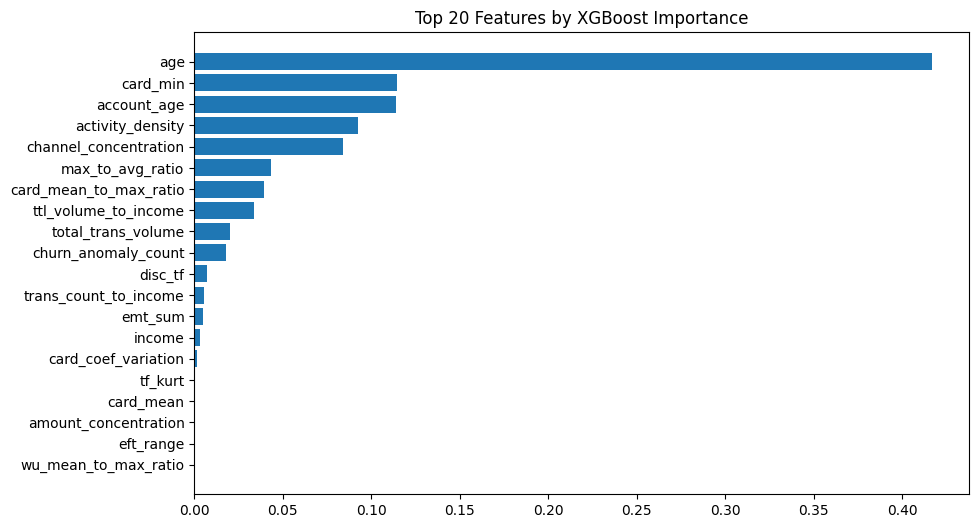

In [190]:
# feature importances for features selection
importances = xgb_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

individual_important_features = feature_importance_df['Feature'].head(20).reset_index().drop(columns='index')

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'][:20], feature_importance_df['Importance'][:20])
plt.gca().invert_yaxis()
plt.title('Top 20 Features by XGBoost Importance')
plt.show()

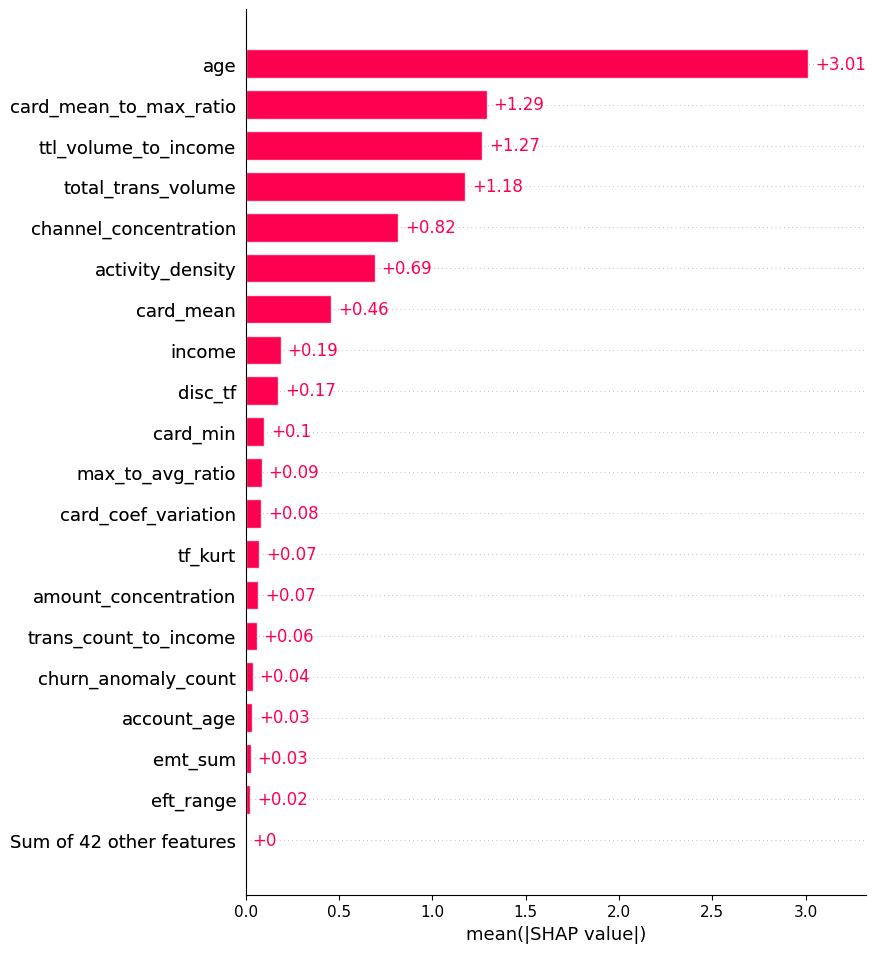

,feature_name,shap_score
51,age,3.013275
15,card_mean_to_max_ratio,1.289558
47,ttl_volume_to_income,1.267300
29,total_trans_volume,1.175768
34,channel_concentration,0.817257
...,...,...
53,sparsity_freq,0.000000
55,disc_time,0.000000
57,tf_entropy,0.000000
58,account_activity_days,0.000000


In [ ]:
# shap value for feature selection
import shap

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer(X)

shap.plots.bar(shap_values, max_display=20)
plt.show()

raw_shap_matrix = shap_values.values
global_shap_importance = np.abs(raw_shap_matrix).mean(axis=0)
feature_importance_df = pd.DataFrame({
    'feature_name': X.columns,
    'shap_score': global_shap_importance
})
feature_importance_df = feature_importance_df.sort_values(by='shap_score', ascending=False)
feature_importance_df

Here's the list of features for isolation forest

In [192]:
individual_important_features = pd.concat([individual_important_features['Feature'],feature_importance_df['feature_name'].head(20)],axis=0).drop_duplicates()
individual_important_features

0                        age
1                   card_min
2                account_age
3           activity_density
4      channel_concentration
5           max_to_avg_ratio
6     card_mean_to_max_ratio
7       ttl_volume_to_income
8         total_trans_volume
9        churn_anomaly_count
10                   disc_tf
11     trans_count_to_income
12                   emt_sum
13                    income
14       card_coef_variation
15                   tf_kurt
16                 card_mean
17      amount_concentration
18                 eft_range
19      wu_mean_to_max_ratio
dtype: object

In [193]:
individual_important_features=individual_important_features.tolist()

#### business important features

In [169]:
from xgboost import XGBClassifier

X = business_features.drop(columns=['customer_id','label']) 
y = business_features['label']

# Calculate the ratio of normal accounts to flagged to handle the extreme imbalance
scale_weight = len(y[y == 0]) / len(y[y == 1])

# Initialize XGBoost with the scale_pos_weight to force it to care about the rare flagged
xgb_model = XGBClassifier(
    scale_pos_weight=scale_weight,
    eval_metric='logloss',
    max_depth=4,        # shallow to prevent overfitting
    random_state=42
)

# Train the model
xgb_model.fit(X, y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

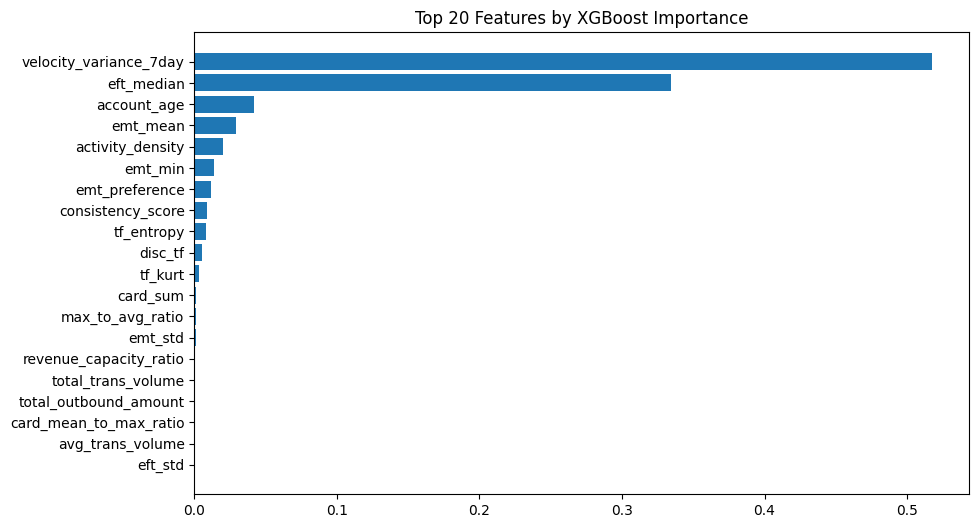

In [170]:
# feature importances for features selection
importances = xgb_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

business_important_features = feature_importance_df['Feature'].head(20).reset_index().drop(columns='index')

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'][:20], feature_importance_df['Importance'][:20])
plt.gca().invert_yaxis()
plt.title('Top 20 Features by XGBoost Importance')
plt.show()

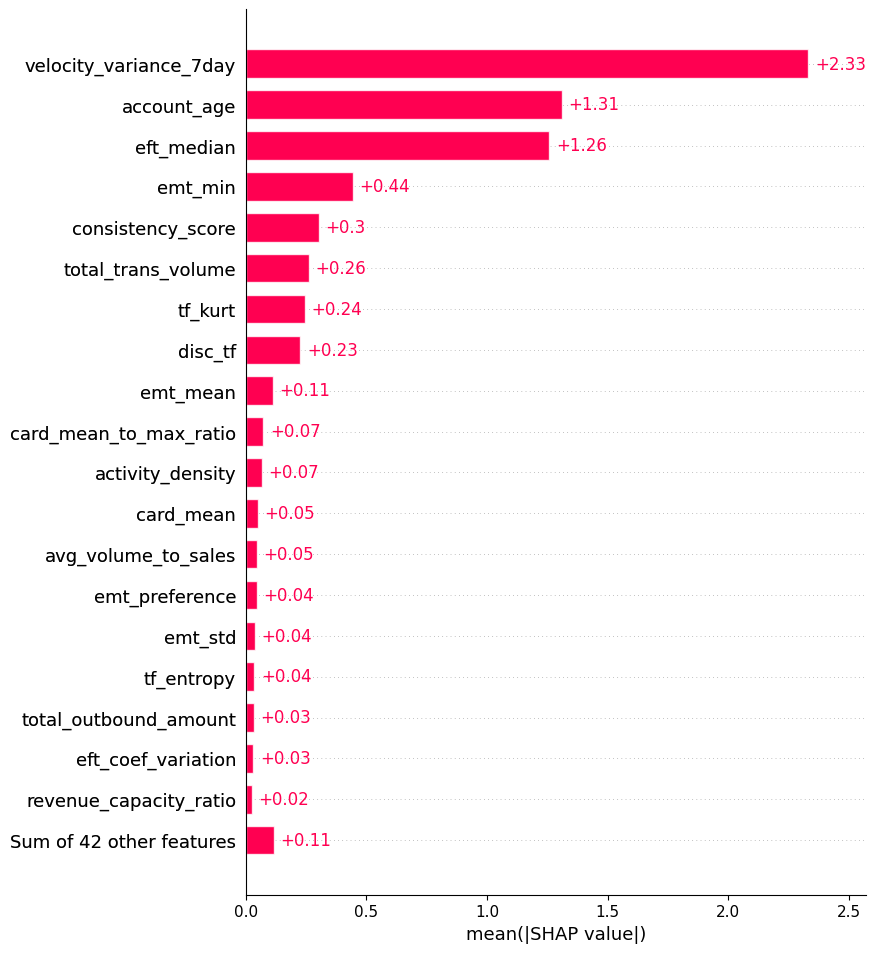

,feature_name,shap_score
60,velocity_variance_7day,2.330817
50,account_age,1.309097
18,eft_median,1.257784
25,emt_min,0.442257
32,consistency_score,0.301628
...,...,...
48,trans_count_to_sales,0.000000
51,age,0.000000
54,sparsity_tf,0.000000
53,sparsity_freq,0.000000


In [171]:
# shap value for feature selection
import shap

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer(X)

shap.plots.bar(shap_values, max_display=20)
plt.show()

raw_shap_matrix = shap_values.values
global_shap_importance = np.abs(raw_shap_matrix).mean(axis=0)

# 3. Create a DataFrame to map the scores back to your feature names
feature_importance_df = pd.DataFrame({
    'feature_name': X.columns,
    'shap_score': global_shap_importance
})
feature_importance_df = feature_importance_df.sort_values(by='shap_score', ascending=False)
feature_importance_df

In [172]:
business_important_features = pd.concat([business_important_features['Feature'],feature_importance_df['feature_name'].head(20)],axis=0).drop_duplicates().tolist()
business_important_features

['velocity_variance_7day',
 'eft_median',
 'account_age',
 'emt_mean',
 'activity_density',
 'emt_min',
 'emt_preference',
 'consistency_score',
 'tf_entropy',
 'disc_tf',
 'tf_kurt',
 'card_sum',
 'max_to_avg_ratio',
 'emt_std',
 'revenue_capacity_ratio',
 'total_trans_volume',
 'total_outbound_amount',
 'card_mean_to_max_ratio',
 'avg_trans_volume',
 'eft_std',
 'card_mean',
 'avg_volume_to_sales',
 'eft_coef_variation']

## Isolation Forest Training

Isolation Forest works by:
1. Randomly selecting features and split values
2. Creating isolation trees
3. Anomalies are isolated earlier (shorter path length)
4. Anomaly score based on average path length across trees

In [173]:
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer

In [215]:
# merge with the labels

individual_features = features[features['customer_id'].isin(kyc_individual['customer_id'])].drop(columns=['ttl_volume_to_sales','trans_count_to_sales','avg_volume_to_sales','revenue_capacity_ratio'])
business_features = features[features['customer_id'].isin(kyc_smallbusiness['customer_id'])].drop(columns=['ttl_volume_to_income','trans_count_to_income','avg_volume_to_income','outbound_to_income_ratio'])

### Isolation Forest for individual accounts

In [216]:
cols_to_keep = ['customer_id'] + individual_important_features
individual_features_selected = individual_features[cols_to_keep].copy()
X = individual_features_selected.copy().drop(columns=['customer_id'])

print(f"Features for modeling: {X.shape[1]}")
print(f"Customers: {X.shape[0]:,}")

print(f"\nMissing values: {X.isnull().sum().sum()}")
print(f"Infinite values: {np.isinf(X).sum().sum()}")

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

Features for modeling: 20
Customers: 52,677

Missing values: 3493
Infinite values: 0


In [217]:
iso_forest = IsolationForest(
    n_estimators=200,          
    max_samples='auto',         
    contamination=0.05,         
    max_features=1.0,          
    random_state=42,
    n_jobs=-1,                
    verbose=1
)

iso_forest.fit(X)

[Parallel(n_jobs=18)]: Using backend ThreadingBackend with 18 concurrent workers.
[Parallel(n_jobs=18)]: Done   2 out of  18 | elapsed:    0.2s remaining:    2.5s
[Parallel(n_jobs=18)]: Done  18 out of  18 | elapsed:    0.3s finished


IsolationForest(contamination=0.05, n_estimators=200, n_jobs=-1,
                random_state=42, verbose=1)

In [218]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# get raw anomaly score: lLower/negative scores = shorter path length (more anomalous)
raw_scores = iso_forest.decision_function(X)

# get the predictions
predictions = iso_forest.predict(X)
is_alerted = np.where(predictions == -1, 1, 0)

# Calculate the 0-100 risk score
inverted_scores = raw_scores * -1
scaler = MinMaxScaler(feature_range=(0, 100))
# .flatten() converts the 2D array from the scaler back into a 1D list
aml_risk_score = scaler.fit_transform(inverted_scores.reshape(-1, 1)).flatten()

individual_features_selected['raw_anomaly_score'] = raw_scores
individual_features_selected['is_alerted'] = is_alerted
individual_features_selected['aml_risk_score'] = aml_risk_score

# Sort by the highest risk score
individual_risk_score = individual_features_selected[['customer_id', 'aml_risk_score', 'raw_anomaly_score', 'is_alerted']].sort_values(by='aml_risk_score', ascending=False)

In [219]:
# divide our customers into high, medium, low risks based on risk score

# high cut off will be 5%, median cut off will be 20%
high_cutoff_raw = individual_risk_score['raw_anomaly_score'].quantile(0.05)
med_cutoff_raw = individual_risk_score['raw_anomaly_score'].quantile(0.20)

conditions = [
    (individual_risk_score['raw_anomaly_score'] <= high_cutoff_raw), 
    (individual_risk_score['raw_anomaly_score'] <= med_cutoff_raw) & (individual_risk_score['raw_anomaly_score'] > high_cutoff_raw),
    (individual_risk_score['raw_anomaly_score'] > med_cutoff_raw)
]

choices = ['High', 'Medium', 'Low']
individual_risk_score['risk_level'] = np.select(conditions, choices, default='Unknown')

# check the distribution of risk levels
print("\nDistribution of Risk Levels:")
print(individual_risk_score['risk_level'].value_counts(normalize=True) * 100)
individual_risk_score


Distribution of Risk Levels:
risk_level
Low       79.998861
Medium    15.000854
High       5.000285
Name: proportion, dtype: float64


,customer_id,aml_risk_score,raw_anomaly_score,is_alerted,risk_level
28600,SYNID0109825639,100.000000,-0.219339,1,High
10649,SYNID0103550907,98.308220,-0.213240,1,High
11606,SYNID0103491795,97.003851,-0.208537,1,High
23365,SYNID0101511348,96.952155,-0.208350,1,High
31977,SYNID0105411519,95.368877,-0.202642,1,High
...,...,...,...,...,...
5097,SYNID0108151570,0.575404,0.139123,0,Low
32282,SYNID0101886667,0.542015,0.139243,0,Low
23056,SYNID0109575654,0.539057,0.139254,0,Low
16878,SYNID0105031347,0.316971,0.140055,0,Low


In [221]:
# Check the accuracy of isolation forest on our labelled data

nonfraud_customers = labels[labels['label'] == 0]['customer_id'].unique()
fraud_customers = labels[labels['label'] == 1]['customer_id'].unique()
print(individual_risk_score[individual_risk_score['customer_id'].isin(fraud_customers)])
print('\n')

           customer_id  aml_risk_score  raw_anomaly_score  is_alerted  \
28798  SYNID0107832828       36.461371           0.009741           0   
6154   SYNID0101421130       26.878236           0.044292           0   
40132  SYNID0107334515       26.802285           0.044565           0   
44184  SYNID0105593361       26.227323           0.046638           0   
2816   SYNID0100957188       24.164267           0.054076           0   
37633  SYNID0107464935       21.788979           0.062640           0   

      risk_level  
28798     Medium  
6154      Medium  
40132     Medium  
44184     Medium  
2816      Medium  
37633        Low  




at least many of our suspicious (labelled 1) accounts are labelled as medium-level risk

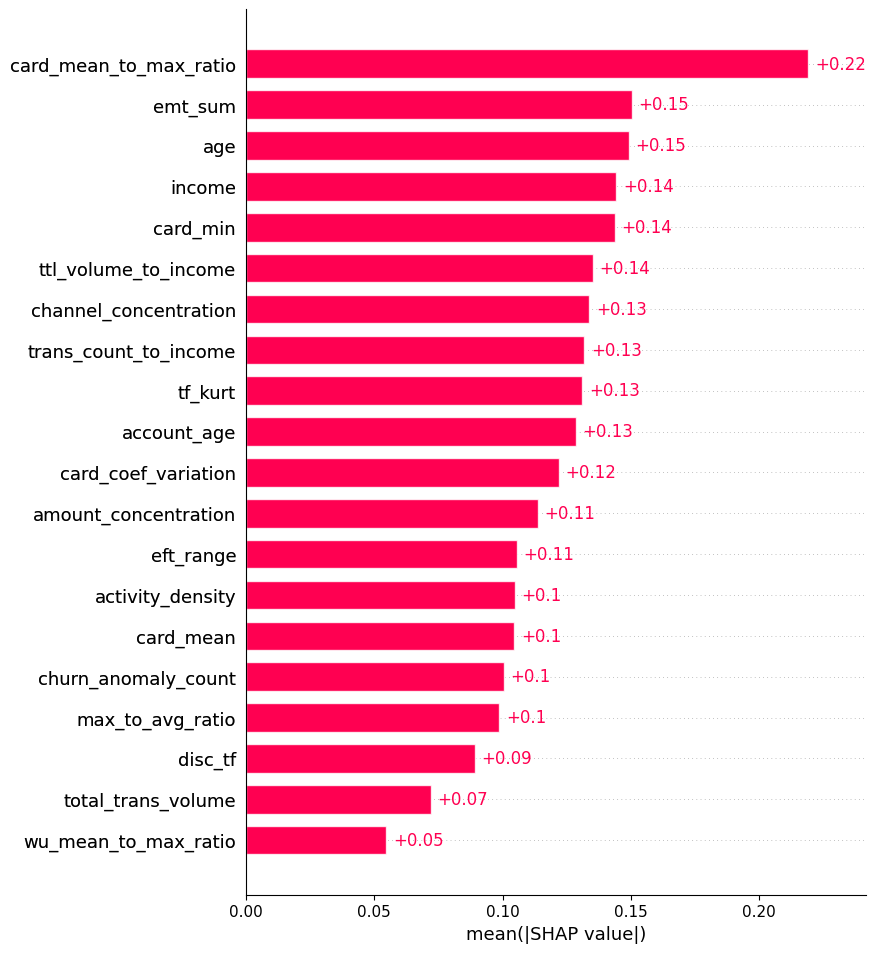

In [203]:
# use SHAP value to explain the model
explainer = shap.TreeExplainer(iso_forest)
shap_values = explainer(X)

shap.plots.bar(shap_values, max_display=20)
plt.show()

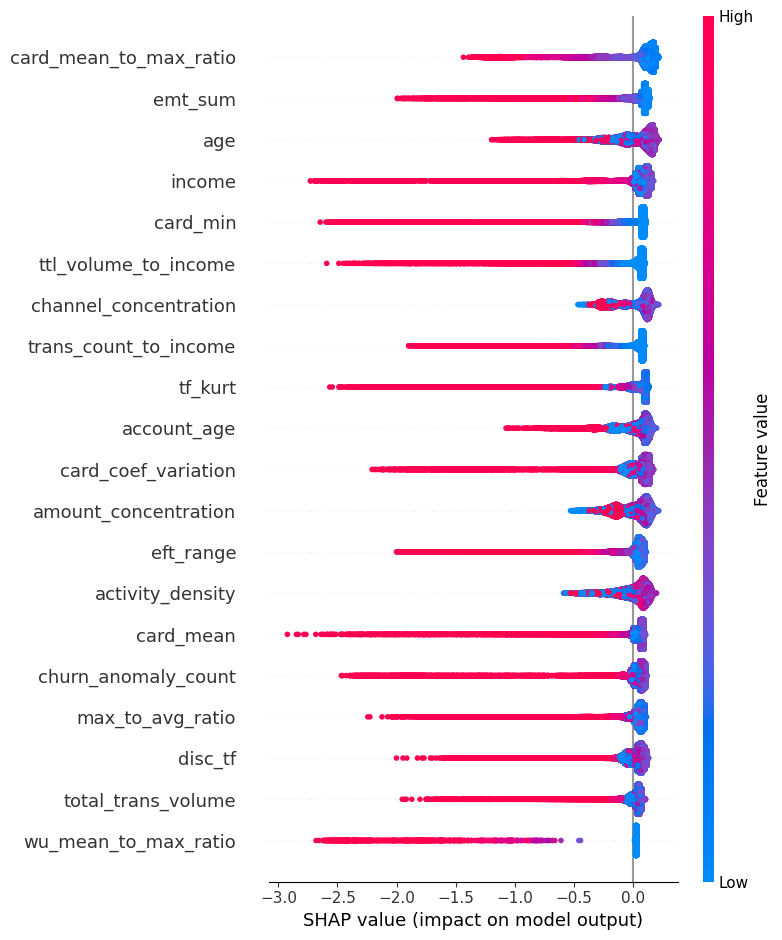

In [204]:
shap.summary_plot(shap_values, X)

### Isolation Forest for small business accounts

In [222]:
cols_to_keep = ['customer_id'] + business_important_features
business_features_selected = business_features[cols_to_keep].copy()
X = business_features_selected.copy().drop(columns=['customer_id'])

print(f"Features for modeling: {X.shape[1]}")
print(f"Customers: {X.shape[0]:,}")

print(f"\nMissing values: {X.isnull().sum().sum()}")
print(f"Infinite values: {np.isinf(X).sum().sum()}")

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

Features for modeling: 23
Customers: 7,641

Missing values: 0
Infinite values: 0


In [223]:
iso_forest = IsolationForest(
    n_estimators=200,          
    max_samples='auto',         
    contamination=0.05,         
    max_features=1.0,          
    random_state=42,
    n_jobs=-1,                
    verbose=1
)

iso_forest.fit(X)

[Parallel(n_jobs=18)]: Using backend ThreadingBackend with 18 concurrent workers.
[Parallel(n_jobs=18)]: Done   2 out of  18 | elapsed:    0.0s remaining:    1.0s
[Parallel(n_jobs=18)]: Done  18 out of  18 | elapsed:    0.2s finished


IsolationForest(contamination=0.05, n_estimators=200, n_jobs=-1,
                random_state=42, verbose=1)

In [224]:
from sklearn.preprocessing import MinMaxScaler

# get raw anomaly score: lLower/negative scores = shorter path length (more anomalous)
raw_scores = iso_forest.decision_function(X)

# get the predictions
predictions = iso_forest.predict(X)
is_alerted = np.where(predictions == -1, 1, 0)

# Calculate the 0-100 risk score
inverted_scores = raw_scores * -1
scaler = MinMaxScaler(feature_range=(0, 100))
# .flatten() converts the 2D array from the scaler back into a 1D list
aml_risk_score = scaler.fit_transform(inverted_scores.reshape(-1, 1)).flatten()

business_features_selected['raw_anomaly_score'] = raw_scores
business_features_selected['is_alerted'] = is_alerted
business_features_selected['aml_risk_score'] = aml_risk_score

# Sort by the highest risk score
business_risk_score = business_features_selected[['customer_id', 'aml_risk_score', 'raw_anomaly_score', 'is_alerted']].sort_values(by='aml_risk_score', ascending=False)

In [225]:
# divide our customers into high, medium, low risks based on risk score

# high cut off will be 5%, median cut off will be 20%
high_cutoff_raw = business_risk_score['raw_anomaly_score'].quantile(0.05)
med_cutoff_raw = business_risk_score['raw_anomaly_score'].quantile(0.20)

conditions = [
    (business_risk_score['raw_anomaly_score'] <= high_cutoff_raw), 
    (business_risk_score['raw_anomaly_score'] <= med_cutoff_raw) & (business_risk_score['raw_anomaly_score'] > high_cutoff_raw),
    (business_risk_score['raw_anomaly_score'] > med_cutoff_raw)
]

choices = ['High', 'Medium', 'Low']
business_risk_score['risk_level'] = np.select(conditions, choices, default='Unknown')

# check the distribution of risk levels
print("\nDistribution of Risk Levels:")
print(business_risk_score['risk_level'].value_counts(normalize=True) * 100)
business_risk_score


Distribution of Risk Levels:
risk_level
Low       79.989530
Medium    14.998037
High       5.012433
Name: proportion, dtype: float64


,customer_id,aml_risk_score,raw_anomaly_score,is_alerted,risk_level
41727,SYNID0200159270,100.000000,-0.218226,1,High
11119,SYNID0200931678,96.826518,-0.206264,1,High
53875,SYNID0200712083,96.444178,-0.204823,1,High
17954,SYNID0200999280,95.408900,-0.200921,1,High
4115,SYNID0200136950,94.927038,-0.199105,1,High
...,...,...,...,...,...
24821,SYNID0200263856,0.321240,0.157483,0,Low
33313,SYNID0200907011,0.305910,0.157541,0,Low
2303,SYNID0200270382,0.280524,0.157636,0,Low
5413,SYNID0200204558,0.115679,0.158258,0,Low


In [226]:
# Check the accuracy of isolation forest on our labelled data

print(business_risk_score[business_risk_score['customer_id'].isin(fraud_customers)])

           customer_id  aml_risk_score  raw_anomaly_score  is_alerted  \
37453  SYNID0200755995       38.655065           0.012995           0   
33214  SYNID0200496670       11.699871           0.114595           0   
24151  SYNID0200755574        9.004467           0.124754           0   
59786  SYNID0200187014        7.043255           0.132146           0   

      risk_level  
37453     Medium  
33214        Low  
24151        Low  
59786        Low  


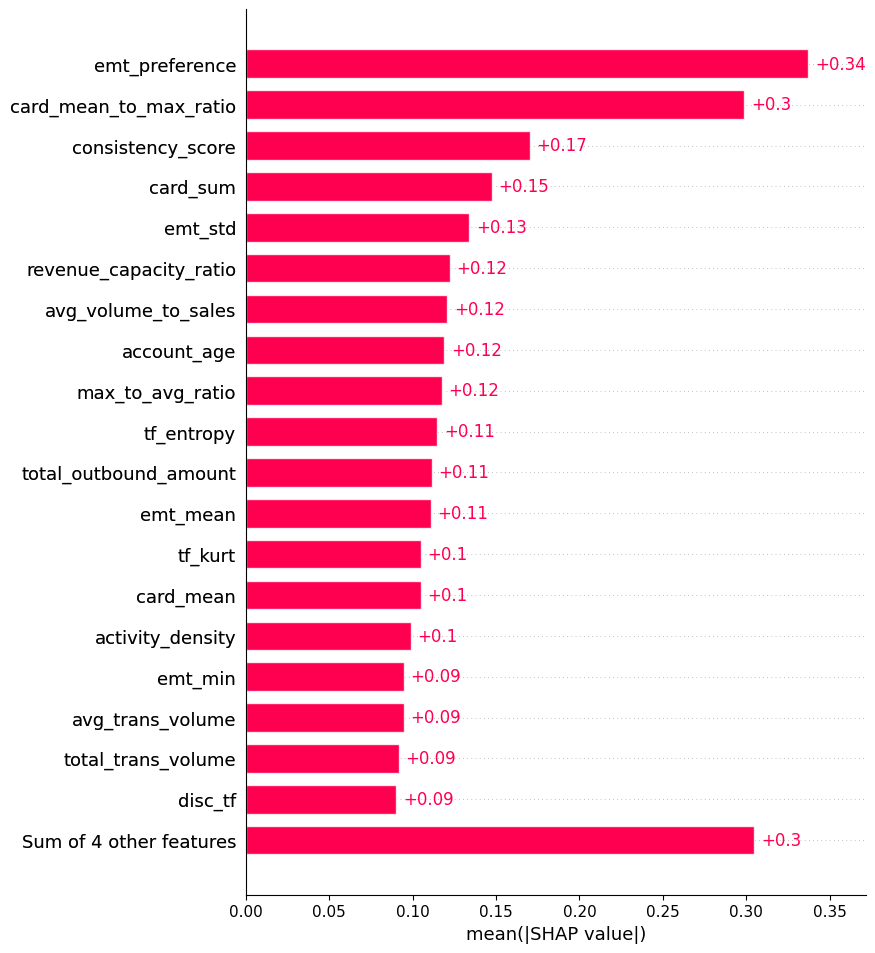

In [210]:
# use SHAP value to explain the model
explainer = shap.TreeExplainer(iso_forest)
shap_values = explainer(X)

shap.plots.bar(shap_values, max_display=20)
plt.show()

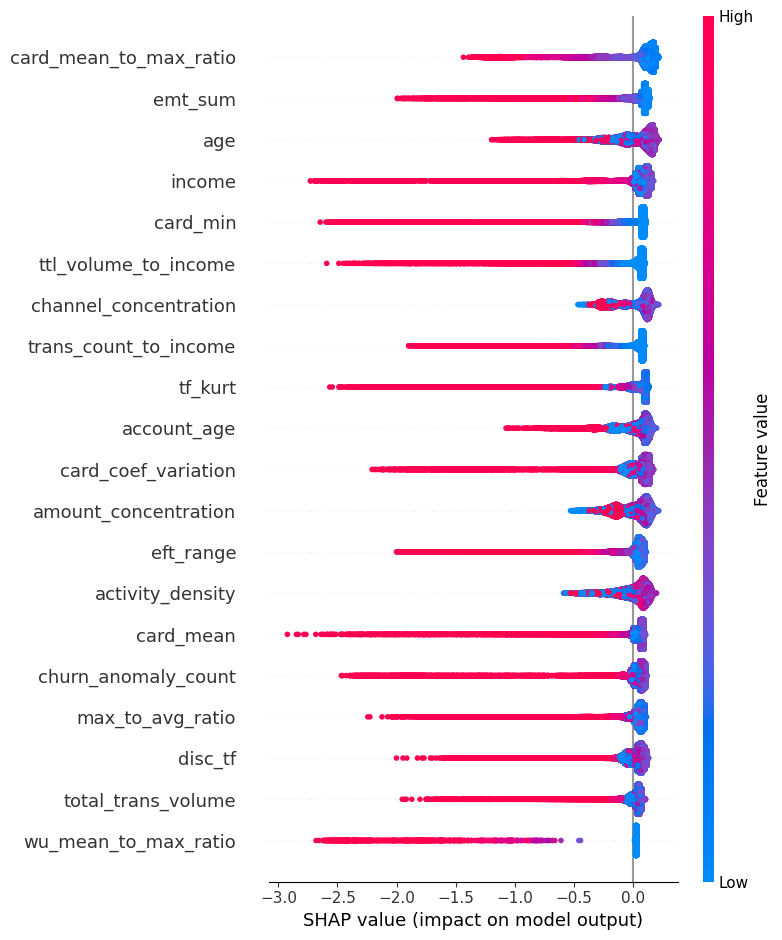

In [ ]:
shap.summary_plot(shap_values, X)

In [227]:
business_risk_score.to_csv('business_accounts_risk_profile.csv')
individual_risk_score.to_csv('individual_accounts_risk_profile.csv')